In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# supaya grafik tampil di notebook
%matplotlib inline

In [2]:
def simulate_queue(jml_mhs, dur_min, dur_max, seed=None):
    rng = np.random.default_rng(seed)
    service = rng.uniform(dur_min, dur_max, jml_mhs)

    data = []
    current_time = 0

    for i in range(jml_mhs):
        start = current_time
        finish = start + service[i]

        data.append({
            "Mahasiswa": i+1,
            "Mulai": start,
            "Durasi": service[i],
            "Selesai": finish
        })

        current_time = finish

    df = pd.DataFrame(data)

    return {
        "events": df,
        "service_times": service,
        "total_time": current_time,
        "avg_service": np.mean(service)
    }

In [3]:
# parameter
n_students = 30
min_dur = 1.0
max_dur = 3.0
seed = 2026

In [4]:
result = simulate_queue(n_students, min_dur, max_dur, seed)

df = result["events"]

df.head()

,Mahasiswa,Mulai,Durasi,Selesai
0,1,0.000000,1.357870,1.357870
1,2,1.357870,2.279826,3.637696
2,3,3.637696,1.934537,5.572233
3,4,5.572233,1.741001,7.313234
4,5,7.313234,1.709835,9.023068


In [5]:
print("=== STATISTIK ===")
print("Total Waktu:", result["total_time"])
print("Rata-rata Durasi:", result["avg_service"])
print("Jumlah Mahasiswa:", n_students)

df.describe()

=== STATISTIK ===
Total Waktu: 59.42945482827663
Rata-rata Durasi: 1.9809818276092213
Jumlah Mahasiswa: 30


,Mahasiswa,Mulai,Durasi,Selesai
count,30.000000,30.000000,30.000000,30.000000
mean,15.500000,29.746214,1.980982,31.727196
std,8.803408,18.085042,0.490987,17.968865
min,1.000000,0.000000,1.025681,1.357870
25%,8.250000,14.753069,1.619393,16.345491
50%,15.500000,31.237258,1.896082,33.578307
75%,22.750000,44.935055,2.299134,47.145282
max,30.000000,57.829472,2.933924,59.429455


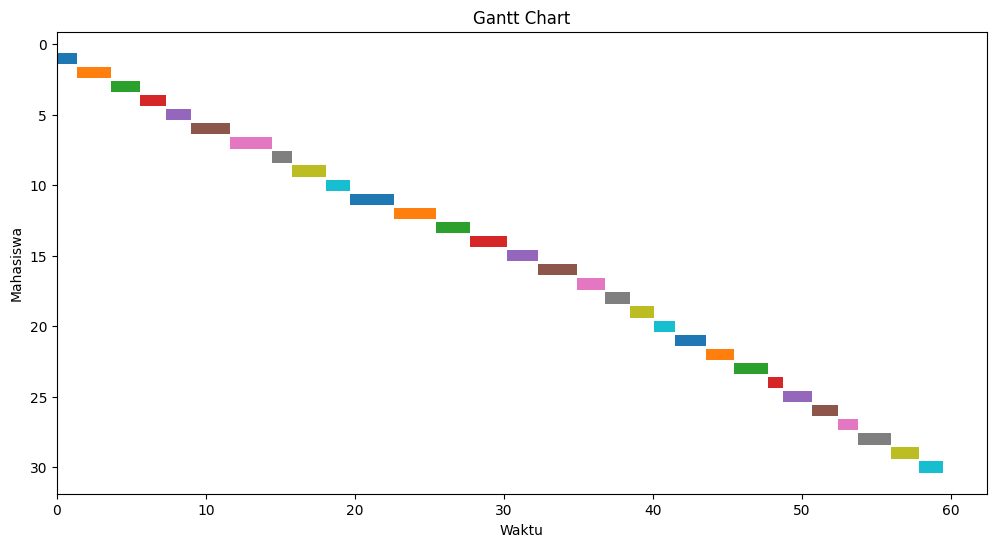

In [6]:
plt.figure(figsize=(12,6))

for _, row in df.iterrows():
    plt.barh(row["Mahasiswa"], row["Durasi"], left=row["Mulai"])

plt.xlabel("Waktu")
plt.ylabel("Mahasiswa")
plt.title("Gantt Chart")
plt.gca().invert_yaxis()

plt.show()

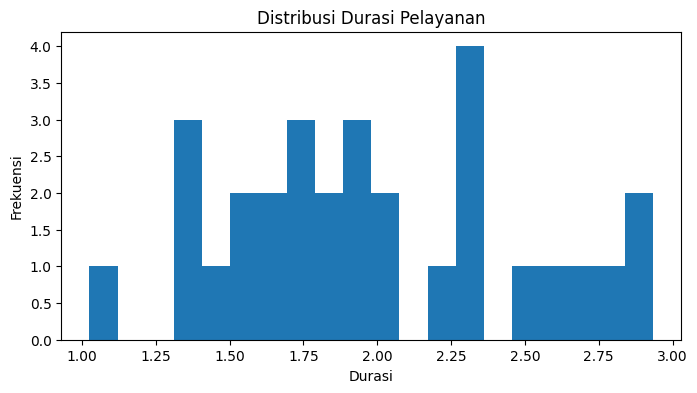

In [7]:
plt.figure(figsize=(8,4))
plt.hist(result["service_times"], bins=20)

plt.title("Distribusi Durasi Pelayanan")
plt.xlabel("Durasi")
plt.ylabel("Frekuensi")

plt.show()

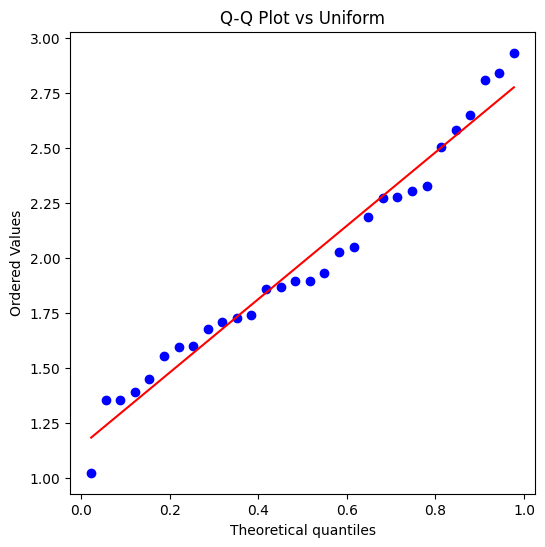

In [8]:
plt.figure(figsize=(6,6))
stats.probplot(result["service_times"], dist="uniform", plot=plt)

plt.title("Q-Q Plot vs Uniform")
plt.show()

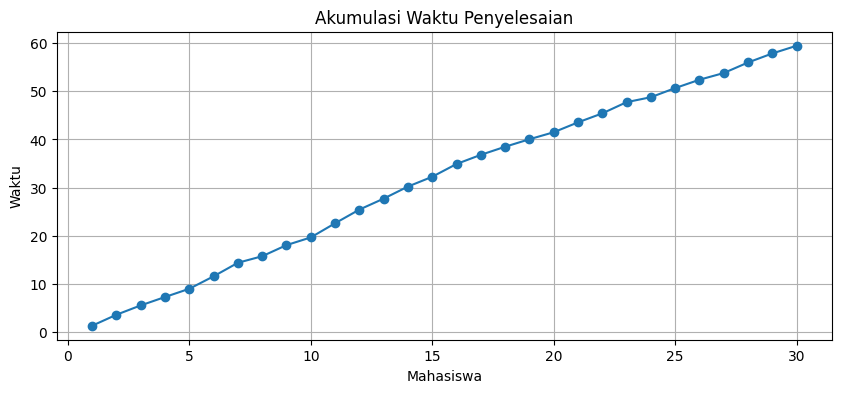

In [9]:
finish = df["Selesai"]

plt.figure(figsize=(10,4))
plt.plot(range(1, len(finish)+1), finish, marker="o")

plt.title("Akumulasi Waktu Penyelesaian")
plt.xlabel("Mahasiswa")
plt.ylabel("Waktu")

plt.grid()
plt.show()

In [10]:
df.to_csv("simulasi_antrian.csv", index=False)
print("✅ File CSV berhasil disimpan!")

✅ File CSV berhasil disimpan!
